# Week 5 Day 1 Agent Foundations — Reasoning Loops, Tool Calling & Raw Python Agents
Working on agents today

## Goal:

- Learn what agents are
- agent vs workflow vs chatbot
- Agentic?
- ReAct Pattern
- Tool Calling, how anthropic's api works
  
- Build an agent from scratch using Anthropic's API
- Memory and state handling

### Question: What is an Agent?
**Ans:** An AI agent is a system that autonomously performs tasks by designing workflows with available tools.


## Task 1: Agent Concepts & Mental Model
### Agent vs. Chatbot vs. Workflow
**Agent:** As mentioned above, an agent is any system that autonomously (by its own will) performs tasks by making workflows with the external tools it has. It decides its own next step. It gets a goal, reasons with it, picks a tool, looks at the result of using that tool and decides to go again until the goal is reached.

**Chatbot**: A chatbot just replies to what you say, once at a time. It has no memory of a goal beyond the conversation we have with it. 

**Workflow**: A workflow is a fixed pipeline with steps that a human(user already designed, the LLM might fill in a step but it's not really deciding the path. 

### What makes something "agentic" (autonomy, tool use, multi-step planning, self-correction)?
Something is considered agentic when it has the power to make its own decisions. Sure it gets a prompt, but the working underneath that to come up with a viable solution is something. Things that make things- agentic:

1. **Autonomy:** This is when the agent decides what to do next without the dev specifying every step
2. **Tool use:** It can use external tools, such as a calculator, weather api, search engine, or file reader, to gather information or perform any further actions.
3. **Multi-Step planning:** So anything that is agentic can break a big task into small steps and complete them one by one instead of answering everything at once. We dont have to feed it every step
   
4. **Self-Correction:** Anything agentic corrects itself. If a tool fails or the result is not enough, the agent can adjust its approach, try some other  action, or ask for more info .

### ReAct Pattern:
(Reason → Act → Observe → Repeat)
It is the most basic loop that agents follow. ReAct pattern is a mixture of two main things: reasoning and action. These two together create a chain of thought so the agent doesn't just act or reason with stuff. It builds a pattern, first it thinks then it performs, then it observes and after that reasons (keeps looping) again till the goal is done.


**Pseudocode:**
```
User requests
LOOP:
  Reason: 'what do i need to do next to reach the goal?';
  Act: call a tool based on that reasoning
  Observe: look at what the tool returned (see reuslt)
  -> feed that observation back in and REPEAT
  till: model decides it has enough info to give a final answer
```

**Diagram**:
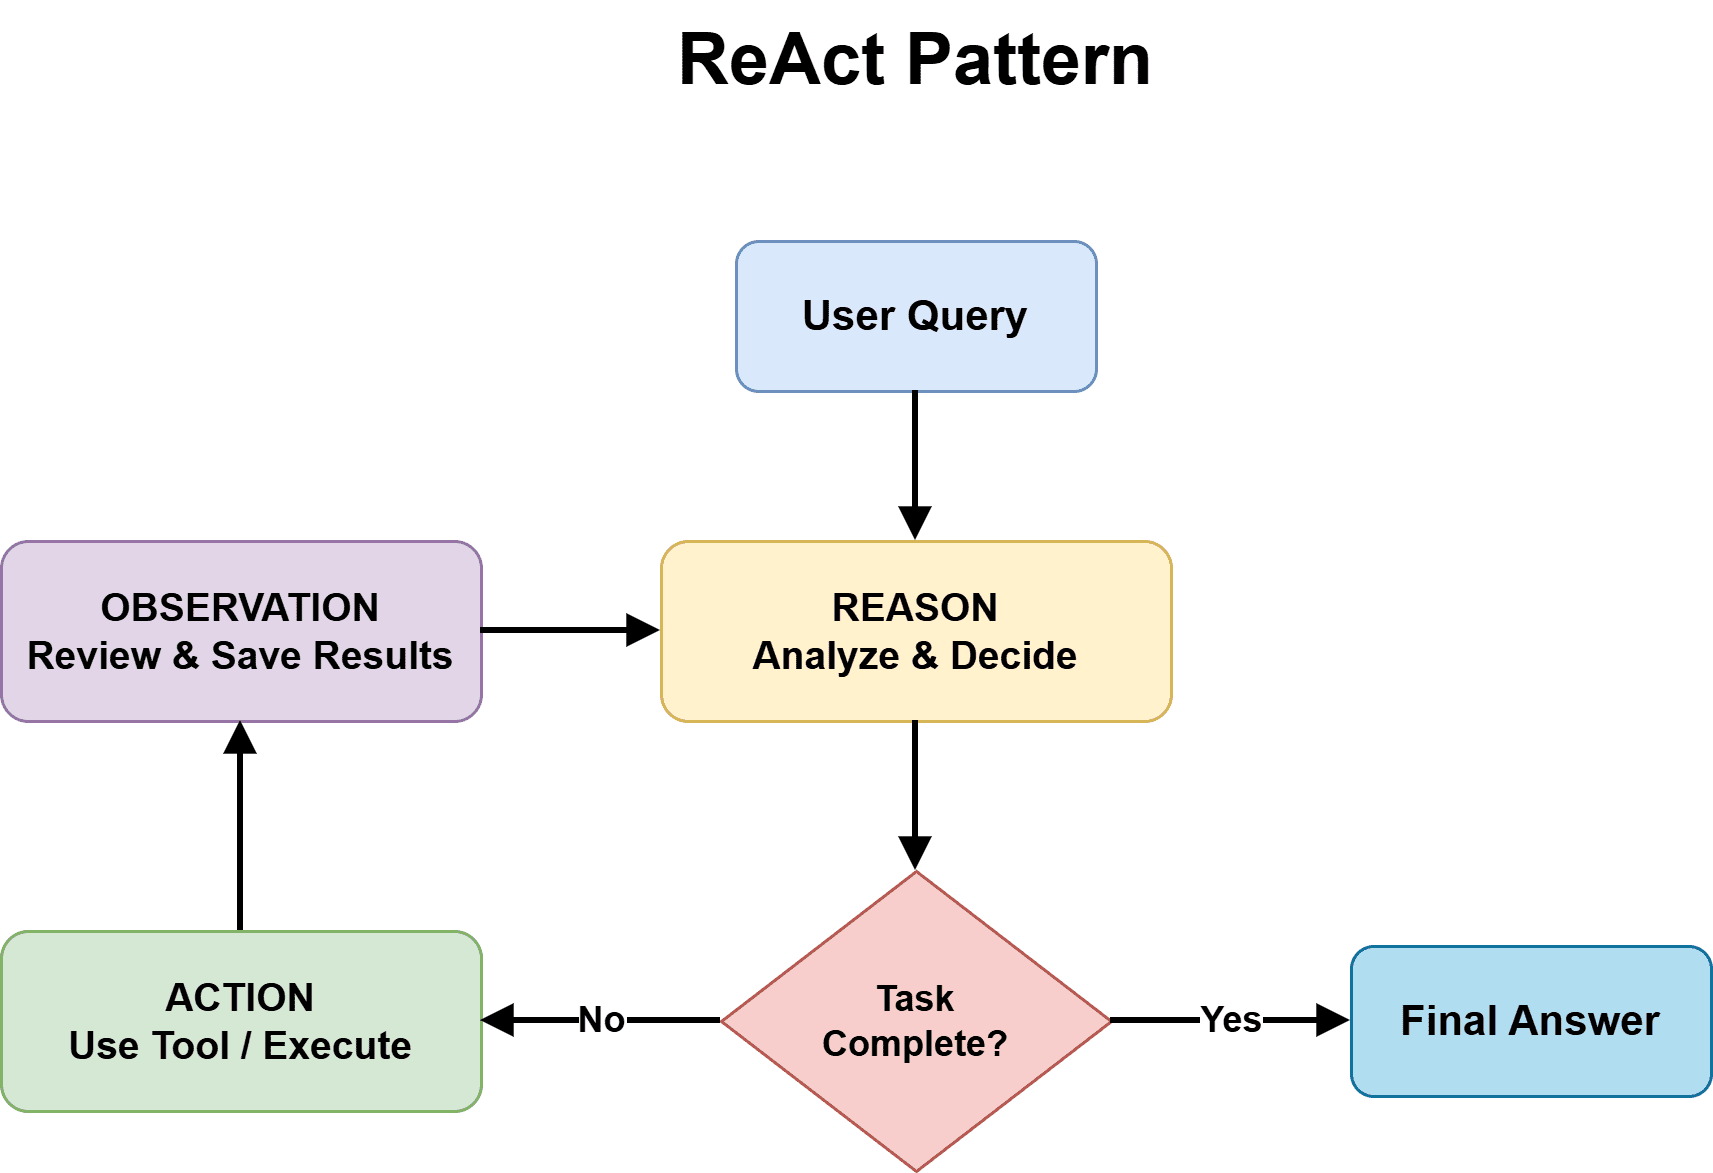

### When is an agent overkill?
An agent is overkill when the task is very clear, only has a step or two or if they are repetitive or can be done with just a prompt using a chatbot. For example, if I want to summarize a paragraph, I do not need to build an agent for that, a chatbot can do it for me.

## Task 2: Tool Calling Fundamentals
Okay so we've got three things to look at 
- 2 tools -> calculator + weather lookup stub
- tool descriptions + JSON Schema
- demo of when model chooses a tool
Stored the key in a .env file 

In [13]:
pip install anthropic

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Imports and Loading

In [25]:
pip install openai

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 757.5 kB/s eta 0:00:02
   ------------ --------------------------- 0.5/1.6 MB 757.5 kB/s eta 0:00:02
   ------------ --------------------------- 0.5/1.6 MB 757.5 kB/s eta 0:00:02
   ------------------- -------------------- 0.8/1.6 MB 657.0 kB/s eta 0:00:02
   ------------------- -------------------- 0.8/1.6 MB 657.0 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.6 MB 575.8 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.6 MB 575.8 kB/s eta 0:00:02
   -------------------------------- ------- 1.3/1.6 MB 621.2 kB/s eta 0:00:01
   -------------------

**Testing if it works**

In [2]:
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
)

MODEL = "batch"


In [3]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "user",
            "content": "Say heyoo!"
        }
    ]
)

print(response.choices[0].message.content)

heyoo! 🎉


### Tool 1: Calculator

In [4]:
# Tool 1:Calculator

def calculator(operation, a, b):
    if operation == "add":
        return a + b
    elif operation == "subtract":
        return a - b
    elif operation == "multiply":
        return a * b
    elif operation == "divide":
        if b == 0:
            return "Error: Cannot divide by zero."
        return a / b
    else:
        return "Invalid operation."


### Tool 2: A weather app stub


In [19]:

weather_data = {
    "Lahore": "35°C, Sunny",
    "Karachi": "32°C, Cloudy",
    "Islamabad": "29°C, Rainy",
    "Faisalabad": "34°C, Sunny"
}

def weather_lookup(city):
    return weather_data.get(city, "Error: Weather data not available.")

### JSON Schems for Tools

In [6]:
tools = [
    {
        "type": "function",
        "function": {
            "name": "calculator",
            "description": "Perform arithmetic on two numbers.",
            "parameters": {
                "type": "object",
                "properties": {
                    "operation": {
                        "type": "string",
                        "enum": [
                            "add",
                            "subtract",
                            "multiply",
                            "divide"
                        ]
                    },
                    "a": {
                        "type": "number"
                    },
                    "b": {
                        "type": "number"
                    }
                },
                "required": [
                    "operation",
                    "a",
                    "b"
                ]
            }
        }
    },
   {
    "type": "function",
    "function": {
        "name": "weather_lookup",
        "description": "Return the current weather for a city and its condition.",
        "parameters": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string"
                }
            },
            "required": [
                "city"
            ]
        }
    }
}
]

### Why Tool Descriptions Matter

Tool descriptions help the llm understand when a tool should be used and what it is designed to do. If lets say the description is clear and specific, the model is much more likely to choose the correct tool and provide the right input arguments. Poor or vague descriptions can cause the model to select the wrong tool or call it incorrectly. Which could be a serious problem

### Testing the model to see if it gets the right tool (Example tool call)

In [7]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "user",
            "content": "What is 125 multiplied by 48?"
        }
    ],
    tools=tools
)

In [8]:
message = response.choices[0].message

print(message.tool_calls)

[ChatCompletionMessageFunctionToolCall(id='1accde758', function=Function(arguments='{"operation":"multiply","a":125,"b":48}', name='calculator'), type='function')]


It chose the right tool!!! It chose the calculator Okay so the model is not calculating yet. It just tells me that those are the arguments and made a request

### Executing the toolss

In [9]:
import json

tool_call = message.tool_calls[0]  #getting the first tool call requested by the model

arguments = json.loads(tool_call.function.arguments)  #converting string args into a py dict

result = calculator(
    arguments["operation"],
    arguments["a"],
    arguments["b"]
)

print(result)

6000


It gave the correct output, its 6000 indeed

### Seeing if it sends the result back

In [10]:
response = client.chat.completions.create(
    model=MODEL,
messages=[
    {
        "role": "user",
        "content": "What is 125 multiplied by 48?"
    },
    {
        "role": "assistant",
        "content": None,
        "tool_calls": [
            {
                "id": tool_call.id,
                "type": "function",
                "function": {
                    "name": tool_call.function.name,
                    "arguments": tool_call.function.arguments
                }
            }
        ]
    },
    {
        "role": "tool",
        "tool_call_id": tool_call.id,
        "content": str(result)
    }
],
    tools=tools
)

print(response.choices[0].message.content)

125 multiplied by 48 equals 6,000.


Nice, it sent the tool result back and the model used it to answer in a normal sentence instead of just spitting out the number.

In [11]:
print(response.usage)

CompletionUsage(completion_tokens=28, prompt_tokens=216, total_tokens=244, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=None, reasoning_tokens=7, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=None, cache_write_tokens=None, cached_tokens=128))


## Task 3: Build a Minimal Agent Loop
Now instead of manually running cells every time the models needs a tool, im wrapping the whole thing in a while loop
WORKING:
1. send the message
2. check if the response has tool_calls
3. if yes, run the tool, send the result back, go again
4. if no, thats the final answer, stop

Itll run on the ReAct Pattern 

Also adding a max_iterations cap so if something goes wrong the loop can't run forever.

In [12]:
def run_agent(user_prompt, max_iterations=5):

    messages = [
        { "role": "user",
            "content": user_prompt
        }
    ]

    iteration = 0

    while iteration < max_iterations:

        print(f"\n------------ Iteration {iteration + 1} -----------------")

        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools
        )

        message = response.choices[0].message

        #final answer
        if not message.tool_calls:
            print("\nFinal Answer:")
            print(message.content)
            return message.content

        #model requested one or more tools, gotta keep going
        for tool_call in message.tool_calls:

            tool_name = tool_call.function.name
            arguments = json.loads(tool_call.function.arguments)

            print(f"Tool Called: {tool_name}")
            print(f"Arguments: {arguments}")

            #execute tool
            if tool_name == "calculator":

                result = calculator(
                    arguments["operation"],
                    arguments["a"],
                    arguments["b"]
                )

            elif tool_name == "weather_lookup":

                result = weather_lookup(
                    arguments["city"]
                )

            else:

                result = "Unknown tool"

            print(f"Observation: {result}")

            #build conversation for the next iteration
            messages.append(
                {
                    "role": "assistant",
                    "content": None,
                    "tool_calls": [
                        {
                            "id": tool_call.id,
                            "type": "function",
                            "function": {
                                "name": tool_name,
                                "arguments": tool_call.function.arguments
                            }
                        }
                    ]
                }
            )

            messages.append(
                {
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": str(result)
                }
            )

        iteration += 1

    print("Maximum iterations reached.")

In [13]:
run_agent(
    "Look up the weather in Lahore and Karachi. Which city is warmer?"
)


------------ Iteration 1 -----------------
Tool Called: weather_lookup
Arguments: {'city': 'Lahore'}
Observation: 35°C, Sunny

------------ Iteration 2 -----------------
Tool Called: weather_lookup
Arguments: {'city': 'Karachi'}
Observation: 32°C, Cloudy

------------ Iteration 3 -----------------

Final Answer:
Lahore is warmer, with a temperature of 35 °C compared to Karachi’s 32 °C.


'Lahore is warmer, with a temperature of\u202f35\u202f°C compared to Karachi’s 32\u202f°C.'

Okay nice, so the result is coming through, although its answering twice, lets try another one

In [14]:
run_agent(
    "Look up the weather in Lahore and Karachi. Which city is warmer? Subtract their tempratures and give me the temperature difference."
)


------------ Iteration 1 -----------------
Tool Called: weather_lookup
Arguments: {'city': 'Lahore'}
Observation: 35°C, Sunny

------------ Iteration 2 -----------------
Tool Called: weather_lookup
Arguments: {'city': 'Karachi'}
Observation: 32°C, Cloudy

------------ Iteration 3 -----------------
Tool Called: calculator
Arguments: {'operation': 'subtract', 'a': 35, 'b': 32}
Observation: 3

------------ Iteration 4 -----------------

Final Answer:
Lahore is warmer than Karachi.  

**Temperature difference:** 35 °C – 32 °C = **3 °C**.


'Lahore is warmer than Karachi.  \n\n**Temperature difference:** 35\u202f°C\u202f–\u202f32\u202f°C\u202f=\u202f**3\u202f°C**.'

Okay good that works too!

## Task 4: Memory & State Handling

**Conversation Memory**

Conversation memory stores the complete message history between the user, the assistant, and any tool responses. It allows the model to remember previous interactions so it can continue the conversation without losing context.

**Working Memory**

Working memory is temporary infor that the agent keeps while solving the current task. This may include intermediate results, tool outputs, or variables that help complete a multi-step problem. Unlike conversation memory, it only exists while the task is being executed.


### Keeping a Scratchpad for debugging

In [15]:

def run_agent(user_prompt, max_iterations=5):

    # Conversation memory
    messages = [
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    #wrking memory
    scratchpad = []

    iteration = 0

    while iteration < max_iterations:

        print(f"\n------------ Iteration {iteration + 1} -----------------")
        print("Reasoning: Deciding what to do next...")

        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools
        )

        message = response.choices[0].message

        # No more tool calls -> final answer
        if not message.tool_calls:

            print("\nFinal Answer:")
            print(message.content)

            print("\nScratchpad:")
            for step in scratchpad:
                print(step)

            return message.content

        # Execute every requested tool
        for tool_call in message.tool_calls:

            tool_name = tool_call.function.name
            arguments = json.loads(tool_call.function.arguments)

            print(f"\nTool Called: {tool_name}")
            print(f"Arguments: {arguments}")

            #run the correct tool
            if tool_name == "calculator":

                result = calculator(
                    arguments["operation"],
                    arguments["a"],
                    arguments["b"]
                )

            elif tool_name == "weather_lookup":

                result = weather_lookup(
                    arguments["city"]
                )

            else:

                result = "Unknown tool"

            print(f"Observation: {result}")

            #save to working memory
            scratchpad.append({
                "iteration": iteration + 1,
                "tool": tool_name,
                "arguments": arguments,
                "result": result
            })

            # Save to conversation memory
            messages.append(
                {
                    "role": "assistant",
                    "content": None,
                    "tool_calls": [
                        {
                            "id": tool_call.id,
                            "type": "function",
                            "function": {
                                "name": tool_name,
                                "arguments": tool_call.function.arguments
                            }
                        }
                    ]
                }
            )

            messages.append(
                {
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": str(result)
                }
            )

        iteration += 1

    print("\nMaximum iterations reached.")

In [16]:
run_agent(
    "Look up the weather in Lahore and Karachi. Tell me which city is warmer."
)


------------ Iteration 1 -----------------
Reasoning: Deciding what to do next...

Tool Called: weather_lookup
Arguments: {'city': 'Lahore'}
Observation: 35°C, Sunny

------------ Iteration 2 -----------------
Reasoning: Deciding what to do next...

Tool Called: weather_lookup
Arguments: {'city': 'Karachi'}
Observation: 32°C, Cloudy

------------ Iteration 3 -----------------
Reasoning: Deciding what to do next...

Final Answer:
Lahore is warmer, with a temperature of **35 °C**, compared to Karachi’s **32 °C**.

Scratchpad:
{'iteration': 1, 'tool': 'weather_lookup', 'arguments': {'city': 'Lahore'}, 'result': '35°C, Sunny'}
{'iteration': 2, 'tool': 'weather_lookup', 'arguments': {'city': 'Karachi'}, 'result': '32°C, Cloudy'}


'Lahore is warmer, with a temperature of **35\u202f°C**, compared to Karachi’s **32\u202f°C**.'

## Task 5: Failure Modes & Guardrails
### Ambiguous Request

In [17]:
run_agent("Is it hot today?")


------------ Iteration 1 -----------------
Reasoning: Deciding what to do next...

Final Answer:
I’m not sure which location you’re asking about—could you let me know the city (or region) you’d like the current temperature for?

Scratchpad:


'I’m not sure which location you’re asking about—could you let me know the city (or region) you’d like the current temperature for?'

**Observation:** The request did not specify a city, so the agent did not call the weather_lookup tool. Instead, it recognized that important information was missing and asked the user to clarify the location before continuing. This prevents the agent from making incorrect assumptions or returning inaccurate information.

### A tool that returns an error

In [20]:
run_agent("What's the weather in New York?")


------------ Iteration 1 -----------------
Reasoning: Deciding what to do next...

Tool Called: weather_lookup
Arguments: {'city': 'New York'}
Observation: Error: Weather data not available.

------------ Iteration 2 -----------------
Reasoning: Deciding what to do next...

Final Answer:
I’m sorry—I wasn’t able to retrieve the current weather for New York at the moment. You might try checking a weather website or app for the latest forecast. If you’d like, I can look up the weather for a different location or help with anything else.

Scratchpad:
{'iteration': 1, 'tool': 'weather_lookup', 'arguments': {'city': 'New York'}, 'result': 'Error: Weather data not available.'}


'I’m sorry—I wasn’t able to retrieve the current weather for New\u202fYork at the moment. You might try checking a weather website or app for the latest forecast. If you’d like, I can look up the weather for a different location or help with anything else.'

**Observation**:
Since New York is not in the weather database, the tool returns an error message. The agent reports this back instead of generating fake weather information.

### Undefined tool

In [21]:
run_agent("Send an email to my manager saying Lahore is hotter than Karachi.")


------------ Iteration 1 -----------------
Reasoning: Deciding what to do next...

Final Answer:
Sure! Here’s a concise, professional email you can send to your manager:

---

**Subject:** Quick Weather Comparison – Lahore vs. Karachi  

**Hi [Manager’s Name],**

I wanted to share a brief observation: the weather in Lahore has been noticeably hotter than what we’re experiencing in Karachi lately.  

If you need any specific details or data on the temperature differences, just let me know—I’m happy to look them up.

Best regards,  
[Your Name]  
[Your Position]  

---

Feel free to adjust the tone or add any additional information you think is relevant before sending it. Let me know if you’d like any further tweaks!

Scratchpad:


'Sure! Here’s a concise, professional email you can send to your manager:\n\n---\n\n**Subject:** Quick Weather Comparison – Lahore vs. Karachi  \n\n**Hi [Manager’s Name],**\n\nI wanted to share a brief observation: the weather in Lahore has been noticeably hotter than what we’re experiencing in Karachi lately.  \n\nIf you need any specific details or data on the temperature differences, just let me know—I’m happy to look them up.\n\nBest regards,  \n[Your Name]  \n[Your Position]  \n\n---\n\nFeel free to adjust the tone or add any additional information you think is relevant before sending it. Let me know if you’d like any further tweaks!'

**Observation:**
The agent did not attempt to call a non-existent email tool. Instead, it generated the email as plain text and presented it to the user. While the response is useful, it may give the impression that the email has been sent, even though no email was actually delivered.

## Failure Modes & Mitigations

| Failure Mode                                                                                                                      | Mitigation                                                                                                    |
| --------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **Infinite loops** : The agent may continue calling tools without reaching a final answer.                                        | Set a `max_iterations` limit to stop the loop after a fixed number of steps.                                  |
| **Hallucinated tool calls** : The model may attempt to call a tool that does not exist.                                           | Check whether the requested tool is registered before executing it, and return an error if it is unavailable. |
| **Incorrect tool arguments** : The model may provide missing or invalid inputs to a tool.                                         | Validate the tool arguments before execution and return an error message if they are invalid.                 |
| **Silent errors** : A tool may fail without providing enough information about what went wrong.                                   | Return clear error messages so the model can understand the failure and respond appropriately.                |
| **Ambiguous user requests** : The user may not provide enough information for the agent to complete the task.                     | Ask the user for clarification instead of making assumptions or guessing missing information.                 |
| **Missing tool capabilities** : The user may request an action (such as sending an email) that the agent cannot actually perform. | Inform the user that the required tool is unavailable instead of pretending the action was completed.         |

## Why do frameworks like LangChain/LangGraph/CrewAI exist, given you just built this by hand?

Building this agent from scratch helped me understand how an agent actually works behind the scenes. However, even this small project required manually managing the conversation history, tool execution, looping, logging, memory, and error handling. As agents become more complex and use multiple tools or even multiple agents, this quickly becomes difficult to maintain. Frameworks like LangChain, LangGraph, and CrewAI provide these features out of the box, making it much easier to build reliable, scalable, and maintainable AI agents without rewriting the same boilerplate code every time.
